# Sampling Langevin dynamics on a graph Ising model

<div class="note"><span class="note-t">TL;DR</span>
<p>We sample the continuous Boltzmann law of a soft-spin graph Ising energy with a custom overdamped-Langevin <code>LangevinGate</code> driven by <code>HybridSampleSimulator</code>. We validate the Metropolis-adjusted (MALA) chain against exact quadrature and compare it with the unadjusted (ULA) chain.</p>
</div>

Overdamped Langevin dynamics is noisy gradient descent on an energy. Repeating the step $x \leftarrow x - \varepsilon\,\nabla V(x) + \sqrt{2T\varepsilon}\,\xi$ with $\xi\sim\mathcal N(0,I)$ drives the state toward the Boltzmann law $\pi(x)\propto e^{-V(x)/T}$: samples concentrate where the energy $V$ is low, with spread set by the temperature $T$.

Each node of a graph carries a real-valued soft spin. Neighboring nodes nudge each other toward alignment while an external field tilts the pattern, so this is a continuous-variable cousin of an Ising sampler.

In this tutorial, we sample that Boltzmann law with `LangevinGate`, custom notebook code built on Torx's `AbstractContinuousGate` interface and defined in the helper module `examples/helpers/_langevin.py`, shown below. Its `sample` method takes one gradient-drift step on the soft-spin energy. We drive it with `HybridSampleSimulator` in two modes, unadjusted (ULA) and Metropolis-adjusted (MALA); the gate section below spells out the difference.

Because the drift $\nabla V$ is nonlinear, this gate has no closed-form affine-Gaussian channel, so we cannot read off exact Gaussian moments the way a linear gate allows. Instead we validate the sampler where the target is tractable, a one-dimensional instance of the same energy whose Boltzmann density we obtain by fine-grid quadrature, and then deploy that same gate on the full graph.

The main steps are:

1. define the soft-spin Ising energy $V$ (continuous spins instead of hard plus or minus one) on a 10-node graph,
2. build the custom `LangevinGate` (ULA and MALA) and sample it with `HybridSampleSimulator`,
3. validate MALA against exact quadrature on a tractable 1-D instance and expose ULA's step-size bias, and
4. deploy the validated MALA gate on the full graph and read off its equilibrium soft-spin field, magnetization, and energy.

This example is the continuous-state companion to the discrete graph notebooks earlier in the series.



## Setup

The setup cells wire the import path and plot styling; `LangevinGate` and its validation utilities come from the helper module `examples/helpers/_langevin.py`.

In [1]:
from pathlib import Path
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import networkx as nx
import numpy as np

from torx.psc import HybridPCircuit, HybridSampleSimulator

In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))

from _notebook_paths import figure_dir
from _notebook_style import (
    apply_notebook_style,
    display_and_close,
    make_savefig,
)
from _langevin import (
    LangevinGate,
    boltzmann_1d_reference,
    ks_distance,
    langevin_theta,
    plot_ks_vs_step,
    plot_mala_reference,
    plot_site_mean_parity,
    plot_ula_bias,
)
import _plots_sampling as P_samp
import _plots_schematics as P_sch

In [3]:
FIGURE_DIR = figure_dir(ROOT)
apply_notebook_style()

SEED = 31

savefig = make_savefig(FIGURE_DIR)

## The graph and soft-spin Ising energy

The target is a 10-node graph: a cycle plus three cross-chords.

That geometry fixes the soft-spin Ising energy. Each node carries a soft spin $s_i = \tanh(x_i)$, $A_{\mathrm{adj}}$ is the adjacency matrix, and

$$V(x) = \underbrace{-\frac{\beta}{2}\, s^\top A_{\mathrm{adj}}\, s}_{\vphantom{\big|}\text{bond energy}} \;-\; h^\top s \;+\; \underbrace{\frac{\lambda_q}{4}\sum_i (x_i^2 - 1)^2}_{\vphantom{\big|}\text{spin well}}, \qquad s_i = \tanh(x_i).$$

The bond term rewards aligned neighbors, the field term $-h^\top s$ tilts the pattern, and the quartic well softly confines each coordinate near $x_i = \pm 1$.

This $V$ is the potential the gate descends, and its Boltzmann law $\pi(x)\propto e^{-V(x)/T}$ is the distribution we sample.

We now build the `graph` and `field` that define the system.

In [4]:
graph = nx.cycle_graph(10)
# Add three long-range chords so the cycle has nonlocal couplings.
graph.add_edges_from([(0, 5), (2, 7), (3, 8)])
pos = nx.spring_layout(graph, seed=SEED)

n = graph.number_of_nodes()
adj = nx.to_numpy_array(graph, dtype=float)
# Antisymmetric field: a per-site tilt from negative to positive that sums to ~0.
field = np.linspace(-0.30, 0.30, n)

In [5]:
assert graph.number_of_nodes() == 10
assert graph.number_of_edges() == 13  # 10 cycle edges + 3 cross-chords
print(f"graph: {n} nodes, {graph.number_of_edges()} edges")

graph: 10 nodes, 13 edges


## The Langevin gate

`LangevinGate` is custom notebook code rather than a Torx API class. It implements the `AbstractContinuousGate` interface and ships with the notebooks; at run time the simulator passes each gate's `theta` to `sample` as `params`. The following is excerpted from `examples/helpers/_langevin.py`:

```python
class LangevinGate(AbstractContinuousGate[dict[str, Array], tuple[int, ...]]):
    ...
    metropolis: bool = eqx.field(static=True, default=False)

    def energy(
        self, x: Float[Array, " d"], theta: dict[str, Array]
    ) -> Float[Array, ""]:
        """Soft-spin quartic Ising energy $V(x)$ that the gate descends."""
        s = jnp.tanh(x)
        coupling = -0.5 * theta["beta"] * (s @ (theta["adj"] @ s))
        bias = -(theta["field"] @ s)
        quartic = 0.25 * theta["lam_quartic"] * jnp.sum((x * x - 1.0) ** 2)
        return coupling + bias + quartic

    def sample(
        self,
        key: Key[Array, ""],
        inputs: Mapping[str, PyTree[Array]],
        params: dict[str, Array],
        ...
    ):
        """Advance the continuous state by one (optionally adjusted) Langevin step."""
        x = inputs["continuous"]
        eps = params["step"]
        temperature = params["temperature"]
        grad_x = jax.grad(self.energy)(x, params)

        noise_key, accept_key = jax.random.split(key)
        ...
            noise = jax.random.normal(noise_key, x.shape, dtype=x.dtype)
        ...

        proposal = x - eps * grad_x + jnp.sqrt(2.0 * temperature * eps) * noise

        if not self.metropolis:
            output = proposal
        else:
            grad_prop = jax.grad(self.energy)(proposal, params)
            # log target ratio: -(V(x') - V(x)) / T
            log_target = (
                -(self.energy(proposal, params) - self.energy(x, params)) / temperature
            )
            # log proposal ratio log q(x | x') - log q(x' | x); the Gaussian
            # proposal has mean y - eps * grad V(y) and covariance 2 T eps I.
            fwd = proposal - (x - eps * grad_x)
            bwd = x - (proposal - eps * grad_prop)
            log_proposal = (jnp.sum(fwd**2) - jnp.sum(bwd**2)) / (
                4.0 * temperature * eps
            )
            accept_prob = jnp.exp(jnp.minimum(0.0, log_target + log_proposal))
            ...
                accepted = jax.random.bernoulli(accept_key, accept_prob)
            ...
            output = jnp.where(accepted, proposal, x)
```

`sample` takes one overdamped-Langevin step on the soft-spin energy above:

$$x' = x \underbrace{-\,\varepsilon\,\nabla V(x)}_{\vphantom{\big|}\text{gradient drift}} + \underbrace{\sqrt{2T\varepsilon}\,\xi}_{\vphantom{\big|}\text{Gaussian noise}},\qquad \xi\sim\mathcal N(0, I).$$

The gradient $\nabla V$ is `jax.grad` applied to the gate's own `energy` method, so the gate descends the same energy it defines. Repeating the step drives the chain toward $\pi(x)\propto e^{-V(x)/T}$. The structural `metropolis` flag selects between two modes:

- ULA (`metropolis=False`) returns the raw proposal. Discretizing the continuous dynamics leaves an $O(\varepsilon)$ bias, so ULA samples a slightly wrong distribution.
- MALA (`metropolis=True`) accepts the proposal with the Metropolis-Hastings probability for $\pi$ and otherwise stays put. The accept/reject step cancels the discretization bias, so MALA is asymptotically exact for $e^{-V/T}$.

The energy coefficients and integrator constants travel in `theta`, exactly as `AffineGaussianGate` carries its $(A, b, \log\mathrm{var})$: `adj`, `field`, `beta`, `lam_quartic`, `step` ($\varepsilon$), and `temperature` ($T$). Below we set the deploy-time constants and pack them into `theta` with the `langevin_theta` helper.

In [6]:
BETA = 0.35
LAM_QUARTIC = 0.6
STEP_SIZE = 0.04
TEMPERATURE = 0.35

DEPLOY_REPS = 1200     # Metropolis-adjusted steps per deployed chain
LONGRUN_REPS = 6000    # a much longer MALA run, used as a convergence reference
NUM_SAMPLES = 1024

In [7]:
theta = langevin_theta(
    adj=adj,
    field=field,
    beta=BETA,
    lam_quartic=LAM_QUARTIC,
    step=STEP_SIZE,
    temperature=TEMPERATURE,
)

`LangevinGate` itself carries the structural pieces (its sites, dims, and the ULA/MALA switch) and reads every physical coefficient from `theta`. The helper below builds the gate in either mode and returns terminal states of independent chains in one JIT-compiled pass.

In [8]:
def terminal_samples(theta, *, metropolis, reps, num_samples, dim, key):
    """Terminal states of `num_samples` independent Langevin chains, one JIT pass."""
    gate = LangevinGate(sites=0, dims=(dim,), metropolis=metropolis)
    circuit = HybridPCircuit([gate], reps=reps)
    simulator = HybridSampleSimulator(num_samples=num_samples)
    compiled = simulator.build_circuit(circuit, [theta])
    initial_state = {
        "discrete": jnp.zeros((0,), dtype=jnp.int32),
        "continuous": jnp.zeros(dim),
    }
    # explicit eqx.filter_jit boundary so the reps-step scan compiles once and
    # is reused across all independent chains
    sampled = eqx.filter_jit(simulator.sample)(compiled, initial_state, key)
    return np.asarray(sampled["continuous"])

One step is a single custom gate acting on the whole dim-10 continuous pmode; `HybridPCircuit` repeats it `reps` times. The ten labeled coordinates are all components of that one pmode rather than ten separate sites, and the dense gate couples every coordinate through $\nabla V$.

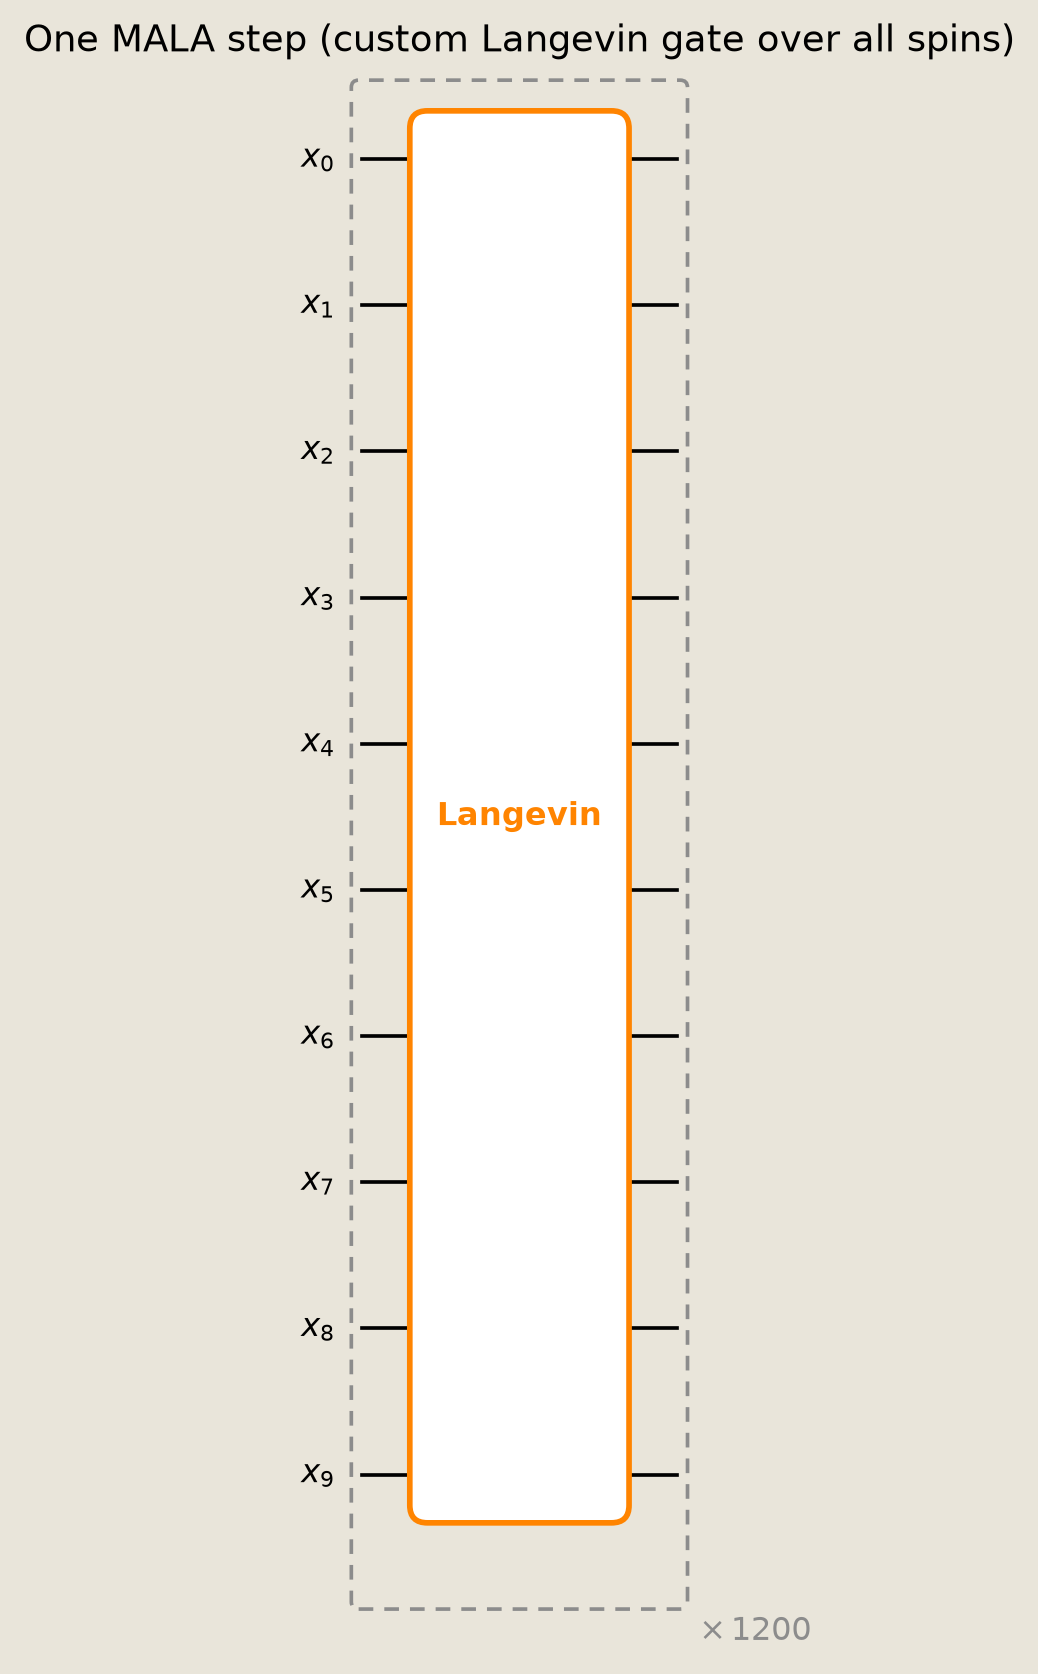

In [9]:
fig = P_sch.draw_pcircuit(
    [("Langevin", list(range(n)))],
    wire_labels=[rf"$x_{{{i}}}$" for i in range(n)],
    title="One MALA step (custom Langevin gate over all spins)",
    reps=DEPLOY_REPS,
)
display_and_close(fig)

## Validating against an exact reference

Because $\nabla V$ is nonlinear, the gate has no affine-Gaussian channel and no closed-form Gaussian moments to check against. We validate the sampler where the target is tractable instead: a single soft spin in the same quartic double-well with a field bias (the couplings switched off), whose Boltzmann density $\pi(x)\propto e^{-V(x)/T}$ we obtain by fine-grid quadrature.

This exercises the same `sample` code path as the graph run below (gradient drift plus, for MALA, the Metropolis accept/reject); only the energy coefficients differ. Matching the 1-D reference therefore validates the proposal-and-acceptance machinery against an exact target; the deployed 10-D chain, which has no tractable reference, is checked separately by long-run-MALA parity below.

To isolate the step-size bias from mixing, we hold the total simulated time $T_{\mathrm{sim}} = \texttt{reps}\times\varepsilon$ fixed across the sweep, so every chain integrates the same amount of dynamics and only the discretization changes.

In [10]:
LAM_1D = 1.5      # a stiffer well than the graph run, to make ULA's bias vivid
T_1D = 0.30
H_1D = 0.25
T_SIM = 60.0      # fixed simulated time; reps = T_sim / step isolates step-size bias
N_1D = 8000

EPS_SWEEP = [0.02, 0.06, 0.11, 0.16]
EPS_MATCH = 0.06  # step for the MALA-matches-reference panel
EPS_BIAS = 0.16   # step for the ULA-bias panel (the coarsest in the sweep)

grid = np.linspace(-3.0, 3.0, 1401)

The `boltzmann_1d_reference` helper evaluates the gate's own `energy` method on the grid and normalizes $e^{-V(x)/T}$ by quadrature, so the target we compare against is the same $V$ the gate descends.

In [11]:
ref_gate = LangevinGate(sites=0, dims=(1,), metropolis=True)
theta_1d = langevin_theta(
    adj=[[0.0]],
    field=[H_1D],
    beta=0.0,
    lam_quartic=LAM_1D,
    step=EPS_MATCH,
    temperature=T_1D,
)
ref_density, ref_cdf = boltzmann_1d_reference(ref_gate, theta_1d, grid)

We sweep the step size for both ULA and MALA, sampling `N_1D` independent chains at each $\varepsilon$ and scoring each empirical marginal against the exact reference with the `ks_distance` helper, a one-sample Kolmogorov-Smirnov statistic.

In [12]:
ula_1d, mala_1d = {}, {}
ks_ula, ks_mala = [], []
for eps in EPS_SWEEP:
    reps = round(T_SIM / eps)  # fixed simulated time T_sim = reps * eps
    theta_eps = langevin_theta(
        adj=[[0.0]],
        field=[H_1D],
        beta=0.0,
        lam_quartic=LAM_1D,
        step=eps,
        temperature=T_1D,
    )
    ula_1d[eps] = terminal_samples(
        theta_eps, metropolis=False, reps=reps, num_samples=N_1D, dim=1,
        key=jax.random.key(SEED + 100),
    )
    mala_1d[eps] = terminal_samples(
        theta_eps, metropolis=True, reps=reps, num_samples=N_1D, dim=1,
        key=jax.random.key(SEED + 200),
    )
    ks_ula.append(ks_distance(ula_1d[eps], grid, ref_cdf))
    ks_mala.append(ks_distance(mala_1d[eps], grid, ref_cdf))

In [13]:
for eps, ku, km in zip(EPS_SWEEP, ks_ula, ks_mala):
    print(f"eps={eps:.2f}  reps={round(T_SIM / eps):5d}  ULA KS={ku:.4f}   MALA KS={km:.4f}")

ks_match = ks_mala[EPS_SWEEP.index(EPS_MATCH)]
ks_bias_ula = ks_ula[EPS_SWEEP.index(EPS_BIAS)]
ks_bias_mala = ks_mala[EPS_SWEEP.index(EPS_BIAS)]

assert ks_match < 0.03, f"MALA does not match the reference: KS {ks_match:.4f}"
assert ks_bias_ula > 0.05, f"ULA bias not visible at eps={EPS_BIAS}: KS {ks_bias_ula:.4f}"
assert ks_bias_ula > 4 * ks_bias_mala, "MALA did not remove ULA's step-size bias"
assert ks_ula[-1] > ks_ula[0], "ULA KS should grow with the step size" 

eps=0.02  reps= 3000  ULA KS=0.0150   MALA KS=0.0061
eps=0.06  reps= 1000  ULA KS=0.0262   MALA KS=0.0043
eps=0.11  reps=  545  ULA KS=0.0476   MALA KS=0.0082
eps=0.16  reps=  375  ULA KS=0.0726   MALA KS=0.0100


The MALA histogram sits on top of the exact Boltzmann density: with the accept/reject step, the chain samples $\pi(x)\propto e^{-V(x)/T}$ to within Monte Carlo noise.

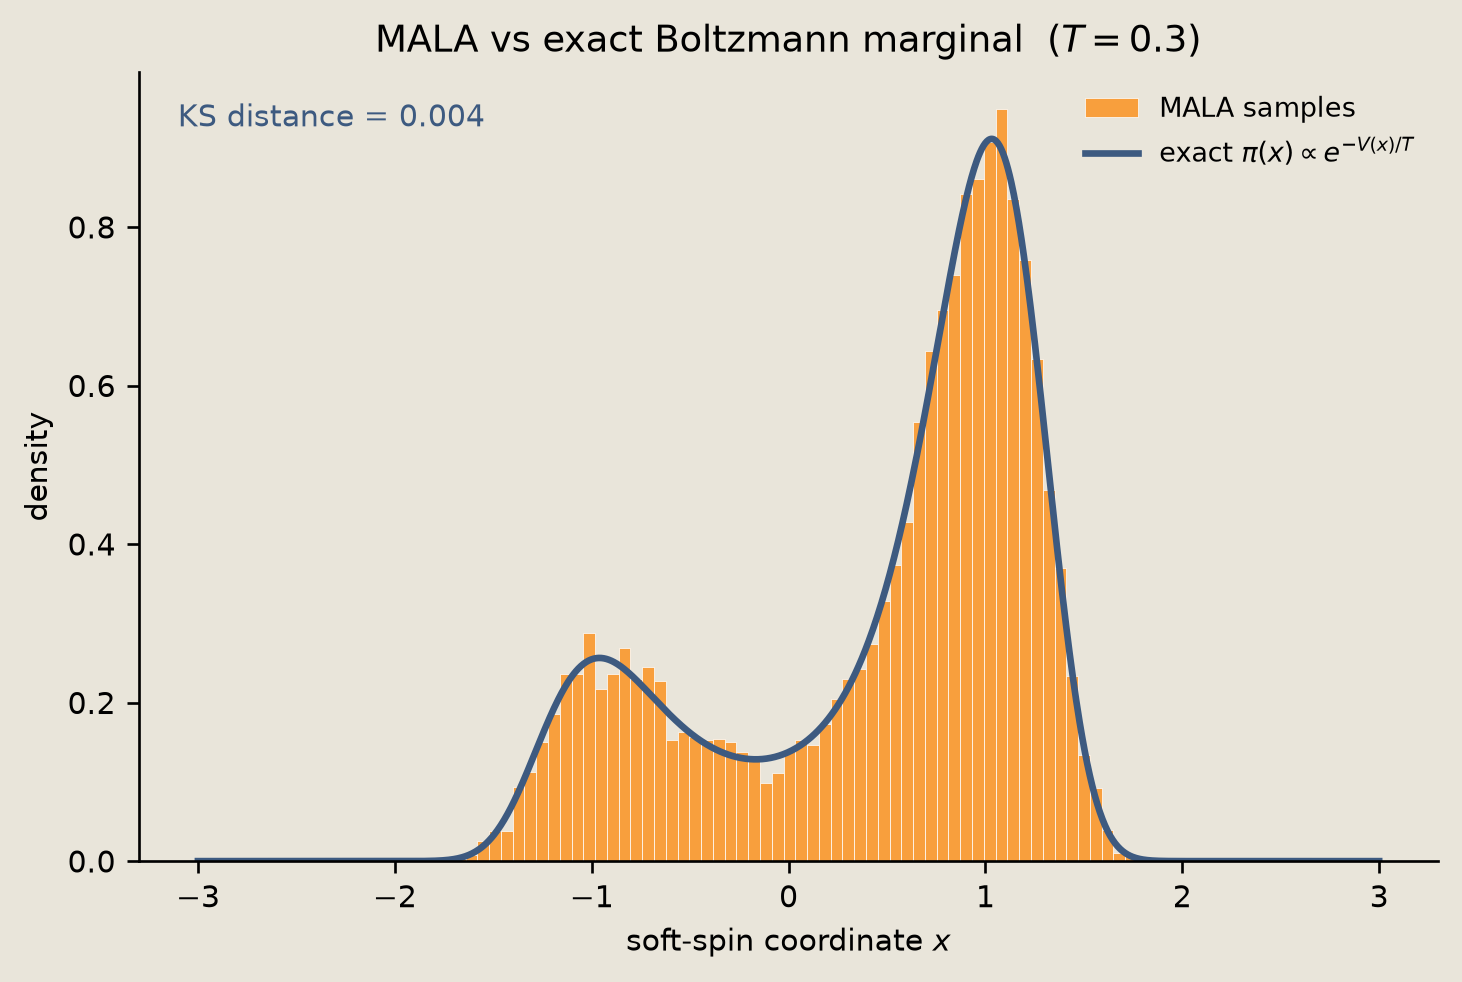

In [14]:
fig = plot_mala_reference(
    grid, ref_density, mala_1d[EPS_MATCH], ks=ks_match, temperature=T_1D
)
savefig(fig, "12_langevin_mala_reference")

At a coarse step the unadjusted chain (ULA) underweights the main mode and overfills the trough relative to the exact density, while MALA, which runs the identical proposal plus accept/reject, stays on the target. That accept/reject step is what removes the bias.

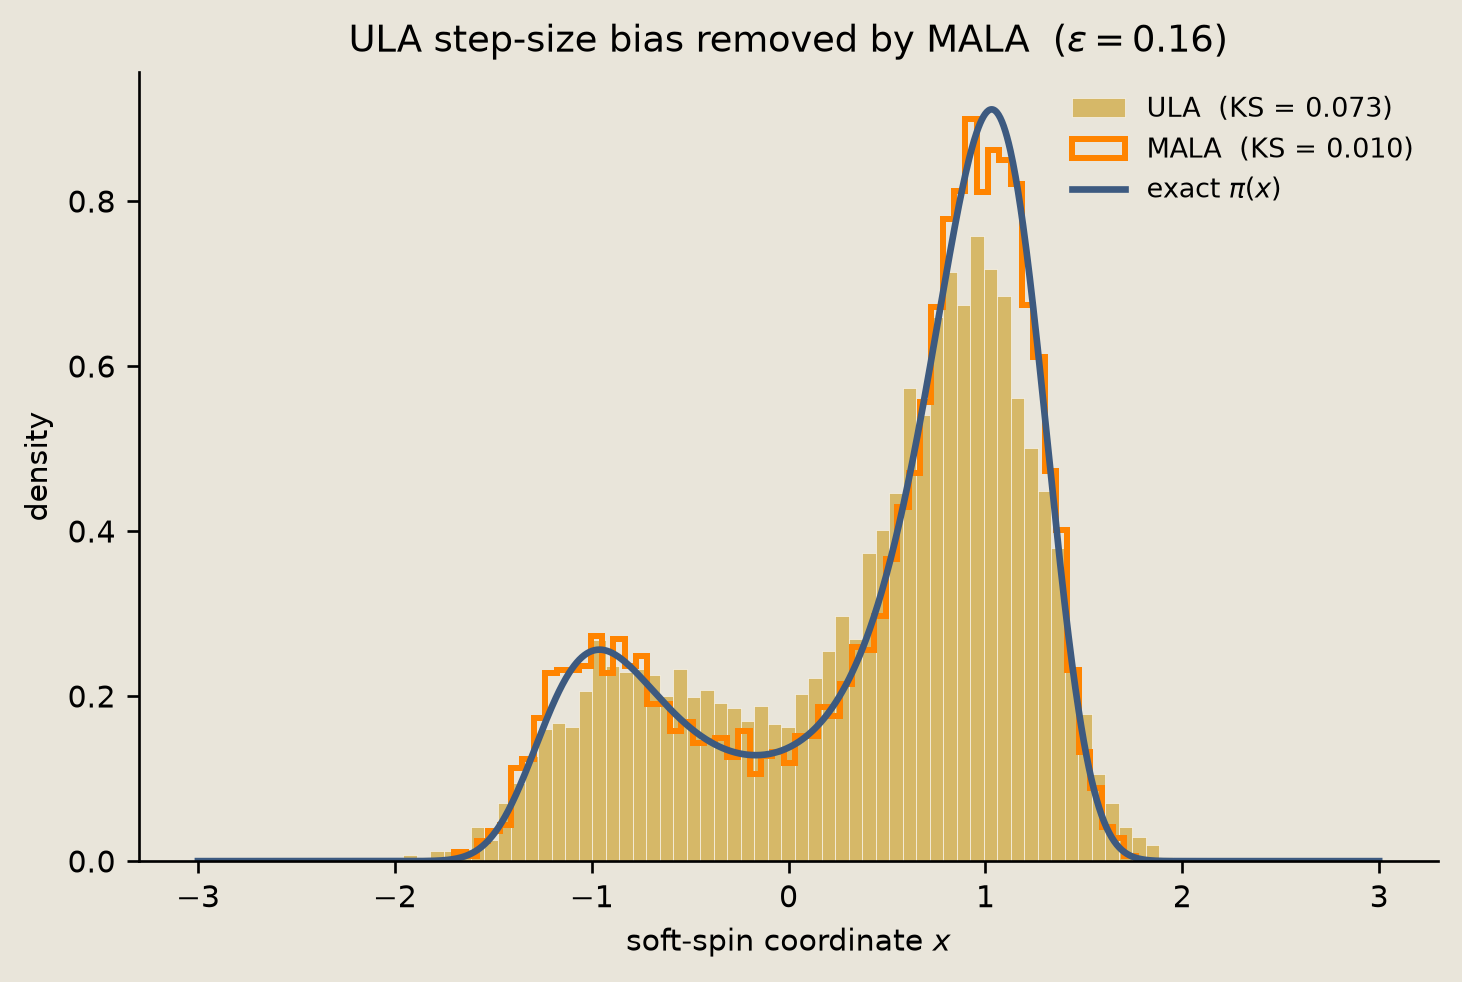

In [15]:
fig = plot_ula_bias(
    grid,
    ref_density,
    ula_1d[EPS_BIAS],
    mala_1d[EPS_BIAS],
    step=EPS_BIAS,
    ks_ula=ks_bias_ula,
    ks_mala=ks_bias_mala,
)
savefig(fig, "12_langevin_ula_bias")

Across the step-size sweep, ULA's KS distance to the exact marginal grows with $\varepsilon$ (its $O(\varepsilon)$ discretization bias), while MALA stays flat near the Monte Carlo floor: the accept/reject correction holds at every step size.

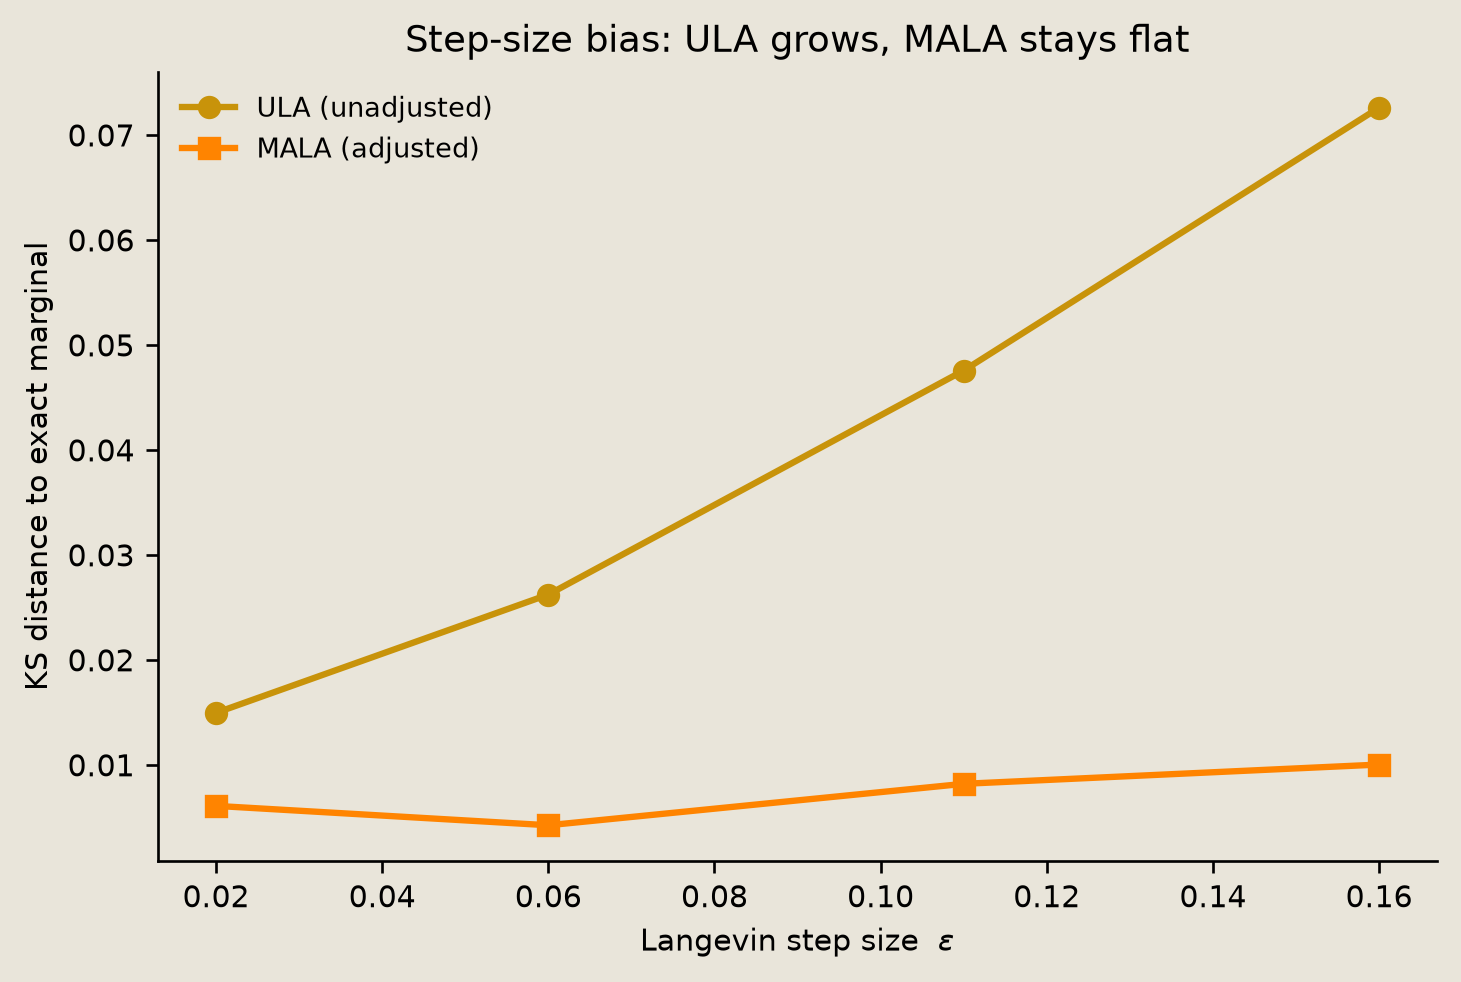

In [16]:
fig = plot_ks_vs_step(EPS_SWEEP, ks_ula, ks_mala)
savefig(fig, "12_langevin_ks_vs_step")

## Sampling the full graph

The 1-D checks validate the sampler's machinery on an exact target. We now deploy that gate on the full 10-node energy: `NUM_SAMPLES` independent chains, each `DEPLOY_REPS` Metropolis-adjusted steps from the zero state, returned in one JIT-compiled pass.

In [17]:
samples = terminal_samples(
    theta, metropolis=True, reps=DEPLOY_REPS, num_samples=NUM_SAMPLES, dim=n,
    key=jax.random.key(SEED),
)
assert samples.shape == (NUM_SAMPLES, n), f"expected ({NUM_SAMPLES}, {n}), got {samples.shape}"
assert np.all(np.isfinite(samples)), "non-finite samples"
print(f"samples shape: {samples.shape}  min={samples.min():.3f}  max={samples.max():.3f}")

samples shape: (1024, 10)  min=-2.156  max=2.235


Is `DEPLOY_REPS` steps enough? With no tractable reference in ten dimensions, we compare per-site mean soft spins $\langle\tanh x_i\rangle$ against a much longer MALA run. Agreement within Monte Carlo error is a convergence sanity check: it is consistent with the deployed chain having reached the stationary law but does not prove it.

In [18]:
long_samples = terminal_samples(
    theta, metropolis=True, reps=LONGRUN_REPS, num_samples=NUM_SAMPLES, dim=n,
    key=jax.random.key(SEED + 1),
)
mu_deploy = np.mean(np.tanh(samples), axis=0)
mu_long = np.mean(np.tanh(long_samples), axis=0)

conv_err = float(np.max(np.abs(mu_deploy - mu_long)))
# Monte Carlo standard error of the per-site mean DIFFERENCE (two independent chains).
se_deploy = np.std(np.tanh(samples), axis=0) / np.sqrt(NUM_SAMPLES)
se_long = np.std(np.tanh(long_samples), axis=0) / np.sqrt(NUM_SAMPLES)
conv_se = float(np.max(np.sqrt(se_deploy**2 + se_long**2)))
print(f"deployed vs long-run per-site max abs diff = {conv_err:.4f}  (max MC SE ~ {conv_se:.4f})")
assert conv_err < 0.06, f"deployed MALA not converged: max abs diff {conv_err:.4f}" 

deployed vs long-run per-site max abs diff = 0.0414  (max MC SE ~ 0.0309)


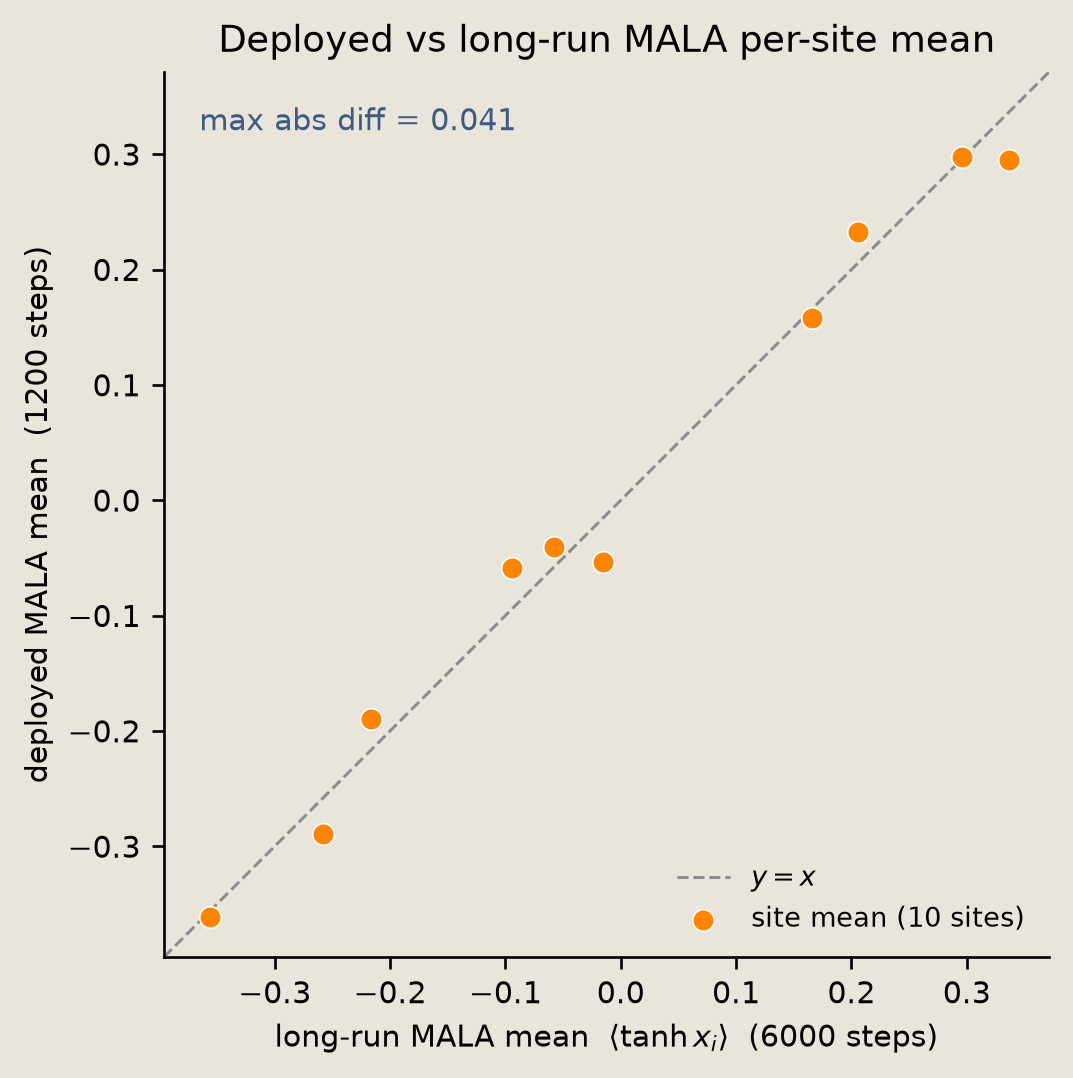

In [19]:
fig = plot_site_mean_parity(
    mu_deploy, mu_long, n=n, reps_short=DEPLOY_REPS, reps_long=LONGRUN_REPS
)
savefig(fig, "12_langevin_convergence_parity")

The deployed and long-run per-site means fall on the diagonal; the max per-site difference is about 1.3x the Monte Carlo standard error, consistent with convergence at this sample size.

## Terminal field and magnetization

We summarize the terminal samples as a soft-spin field and a magnetization distribution.

The graph view shows the mean soft spin $\tanh(x_i)$ over `NUM_SAMPLES` samples on the graph. A diverging colormap fits here because magnetization is signed.

We compute these summaries from the terminal states.

In [20]:
mean_soft_spin = np.mean(np.tanh(samples), axis=0)
terminal_magnetization = np.mean(np.tanh(samples), axis=1)
mean_mag = float(terminal_magnetization.mean())

The terminal field plot puts one labeled node at each graph site.

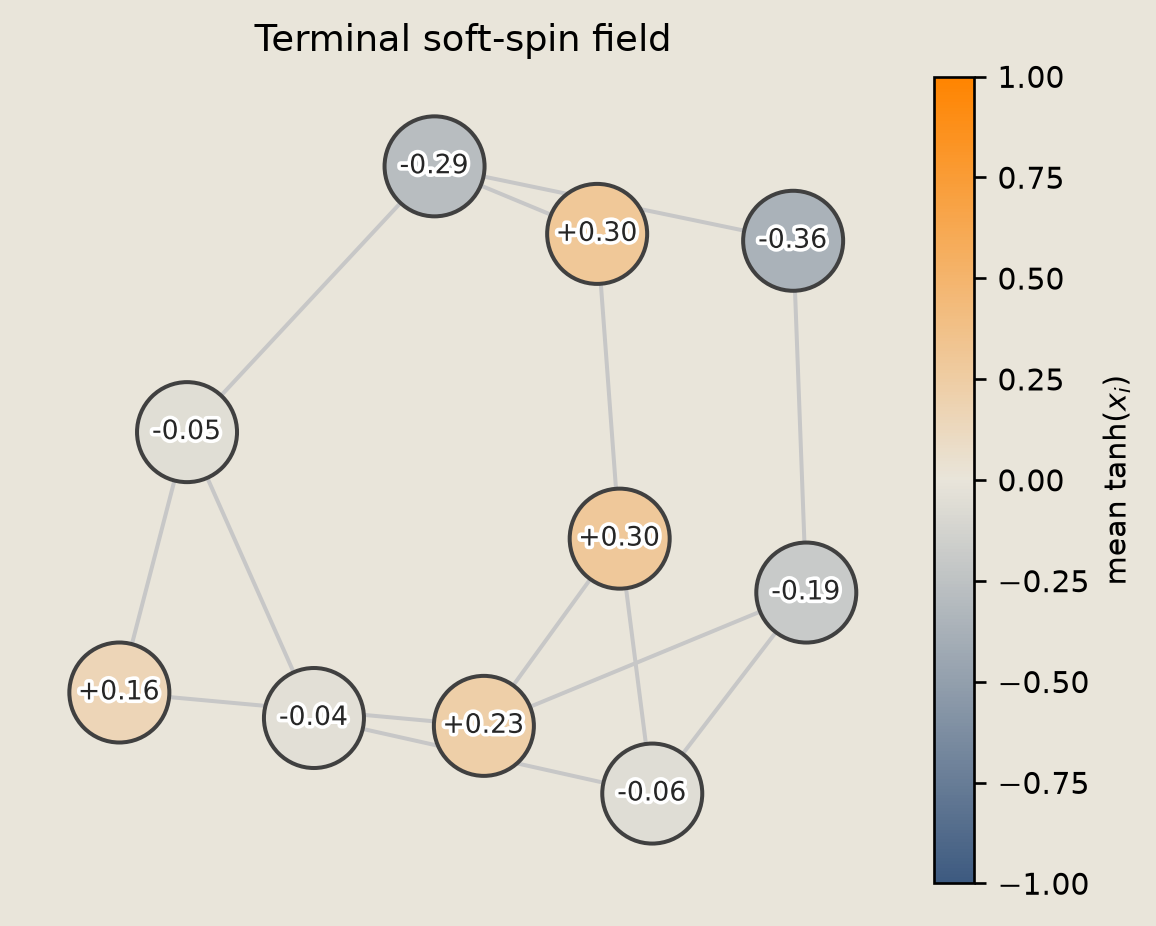

In [21]:
fig = P_sch.plot_terminal_field(graph, pos, mean_soft_spin)
savefig(fig, "12_langevin_terminal_field")

The magnetization histogram shows the per-path magnetization $m = \frac{1}{n}\sum_i \tanh(x_i)$ with the sample mean marked.

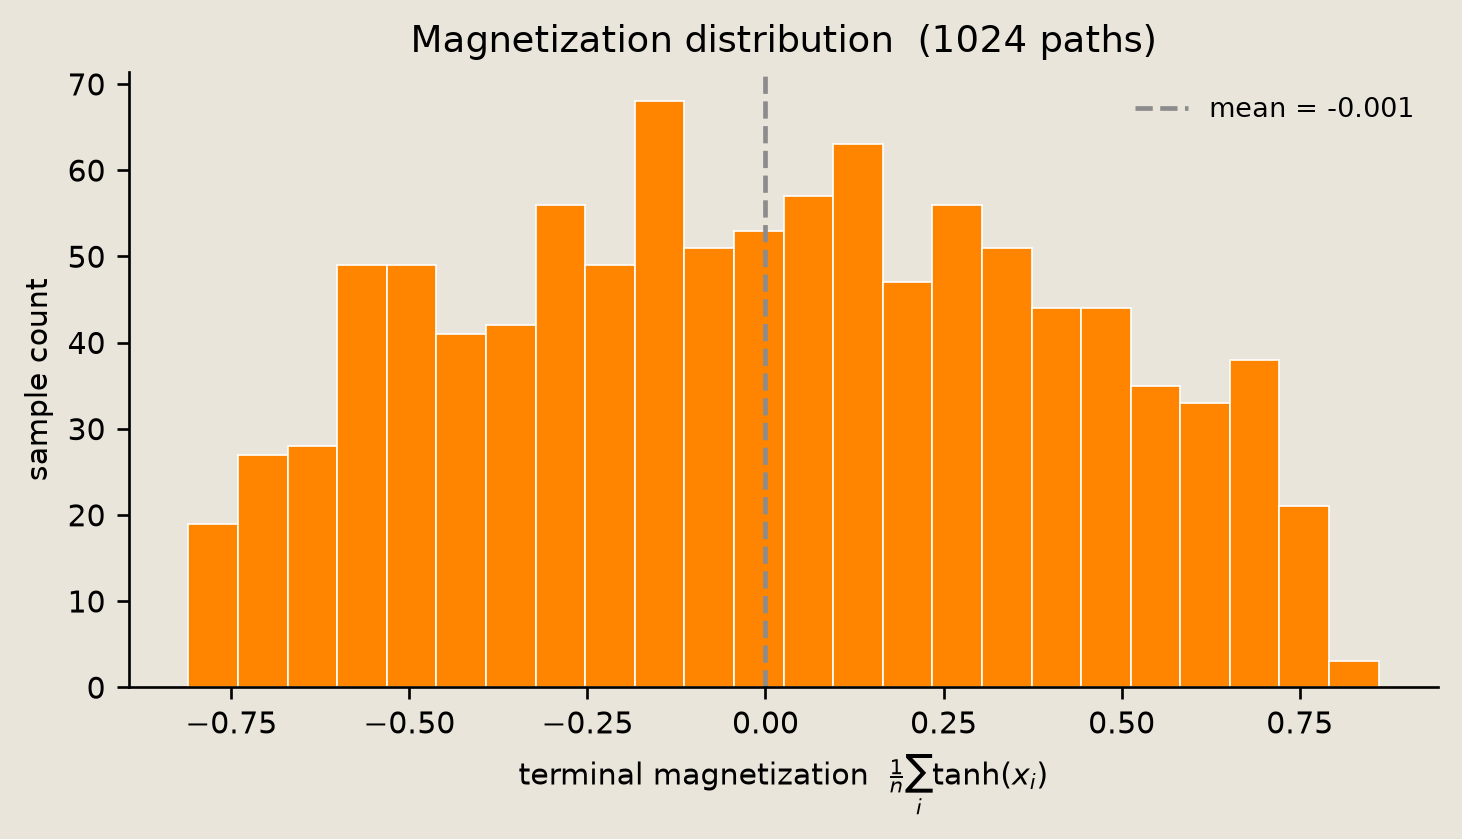

In [22]:
fig = P_samp.plot_magnetization_histogram_langevin(
    terminal_magnetization,
    title_hist=f"Magnetization distribution  ({NUM_SAMPLES} paths)",
)
savefig(fig, "12_langevin_magnetization")

The external field is antisymmetric (it sums to about zero), so at equilibrium it induces per-site magnetization structure rather than a net polarization. The graph coloring above shows signed per-site structure consistent with the field, and the per-path magnetization distribution is broad but centered on zero (mean -0.001). These are equilibrium statistics of the Boltzmann law the gate samples, read from the converged terminal states.

## Energy equilibration

A single MALA path scores its own energy $V(x_t)$ as it evolves. Starting from $x = 0$ every term except the quartic well vanishes, so $V(x_0) = \tfrac{\lambda_q}{4}\,n$. The energy then relaxes and fluctuates around an equilibrium band, the finite-temperature signature of Boltzmann sampling rather than descent to a single minimum.

We unroll one path with a compiled scan, recording $V(x_t)$ and the MALA acceptance rate along the way.

In [23]:
def run_mala_path(theta, *, dim, steps, key):
    """One MALA path: return (energies V(x_t) over the path, acceptance rate)."""
    gate = LangevinGate(sites=0, dims=(dim,), metropolis=True)

    def body(carry, _):
        x, k = carry
        k, subkey = jax.random.split(k)
        substate = {"discrete": jnp.zeros((0,), dtype=jnp.int32), "continuous": x}
        x_next = gate.sample(subkey, substate, theta)
        moved = jnp.any(jnp.abs(x_next - x) > 0.0)  # a rejection leaves x unchanged
        return (x_next, k), (x, moved)

    # one compiled scan unrolls the whole trajectory; no per-step host sync
    _, (path, moved) = eqx.filter_jit(
        lambda key: jax.lax.scan(body, (jnp.zeros(dim), key), None, length=steps)
    )(key)
    energies = jax.vmap(lambda x: gate.energy(x, theta))(path)
    return np.asarray(energies), float(np.mean(np.asarray(moved)))

In [24]:
TRACE_STEPS = 500
energies_arr, accept_rate = run_mala_path(
    theta, dim=n, steps=TRACE_STEPS, key=jax.random.key(SEED + 2)
)
assert np.all(np.isfinite(energies_arr)), "non-finite energy trace"

mean_energy = float(energies_arr.mean())
initial_energy = float(energies_arr[0])
tail_energy = float(energies_arr[-100:].mean())  # late-trace level shown in the figure and summary

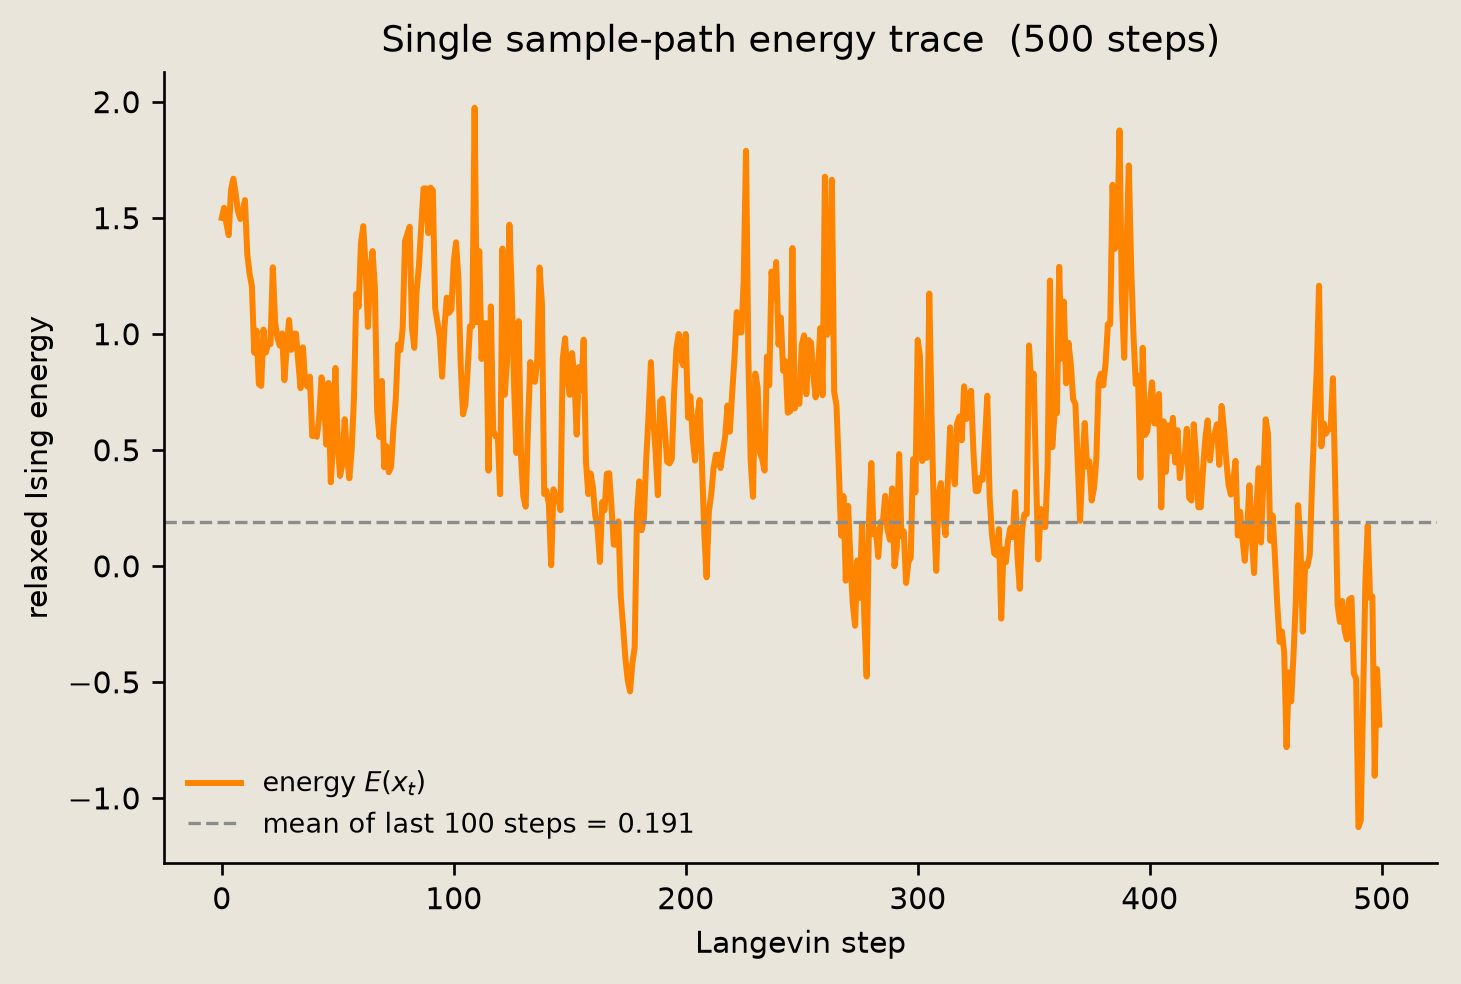

In [25]:
fig = P_samp.plot_energy_trace(energies_arr, tail_energy)
savefig(fig, "12_langevin_energy_trace")

The energy drops from $V(x_0)$ and then fluctuates around a level well below the start, with fluctuations set by the temperature. The dashed line marks the mean of the last 100 steps, the same value the summary below prints; this single noisy path is still drifting slowly late in the trace, so we read the level as approximate.

## Verification

We close with checks the earlier cells do not already cover: the MALA acceptance rate is healthy, the energy trace equilibrates well below its initial value, and the net magnetization is near zero. A summary block then prints the headline numbers.

In [26]:
assert accept_rate > 0.5, f"MALA acceptance too low: {accept_rate:.3f}"
assert np.isfinite(mean_energy), "mean energy is non-finite"
assert energies_arr.min() < initial_energy, "energy never descended below initial value"
assert tail_energy < initial_energy - 0.1 * abs(initial_energy), (
    f"energy did not equilibrate below the start: tail {tail_energy:.3f} vs "
    f"initial {initial_energy:.3f}"
)
assert abs(mean_mag) < 0.15, f"unexpected net polarization: mean magnetization {mean_mag:+.4f}" 

In [27]:
print(f"-- Langevin graph Ising  (n={n}, deploy reps={DEPLOY_REPS}, {NUM_SAMPLES} paths) --")
print(f"  MALA acceptance rate  : {accept_rate:.3f}")
print(f"  deployed vs long-run  : max |d mean| = {conv_err:.4f}  (MC SE ~ {conv_se:.4f})")
print(f"  mean magnetization    : {mean_mag:+.4f}   (range [-1, 1])")
print(
    f"  magnetization range   : [{terminal_magnetization.min():+.3f}, {terminal_magnetization.max():+.3f}]"
)
print(f"  initial energy V(x_0) : {initial_energy:+.4f}")
print(f"  equilibrium energy    : {tail_energy:+.4f}  (mean of last 100 steps)")
print(f"  1-D MALA KS (eps={EPS_MATCH}): {ks_match:.4f}")
print(f"  1-D ULA  KS (eps={EPS_BIAS}): {ks_bias_ula:.4f}   (step-size bias MALA removes)")
print("--------------------------------------------------------")

-- Langevin graph Ising  (n=10, deploy reps=1200, 1024 paths) --
  MALA acceptance rate  : 0.974
  deployed vs long-run  : max |d mean| = 0.0414  (MC SE ~ 0.0309)
  mean magnetization    : -0.0008   (range [-1, 1])
  magnetization range   : [-0.810, +0.861]
  initial energy V(x_0) : +1.5000
  equilibrium energy    : +0.1910  (mean of last 100 steps)
  1-D MALA KS (eps=0.06): 0.0043
  1-D ULA  KS (eps=0.16): 0.0726   (step-size bias MALA removes)
--------------------------------------------------------


## Conclusion

We sampled the continuous Boltzmann law of a soft-spin graph Ising energy with a custom `LangevinGate`.

The gate takes one gradient-drift step on $V$, with the gradient computed by `jax.grad` inside `sample`; `HybridPCircuit` repeats it and `HybridSampleSimulator` returns terminal states of independent chains in one JIT-compiled pass. On a tractable 1-D instance, the Metropolis-adjusted (MALA) chain matched the exact quadrature density; the step-size sweep quantified the unadjusted (ULA) bias it removes. Deployed on the full graph, MALA reached the same per-site statistics as a long-run reference, its energy equilibrated, and the soft-spin field showed the field-induced gradient.

Because the drift is nonlinear, the gate forfeits the closed-form affine-Gaussian moment simulator, so correctness is established by comparison to a tractable reference instead.

Next, [`13_regime_switching_diffusion.ipynb`](13_regime_switching_diffusion.ipynb) drives a Gaussian process with a discrete control pdit.

## References

1. Roberts, G.O., Tweedie, R.L. 1996. [*Exponential convergence of Langevin distributions and their discrete approximations*](https://projecteuclid.org/journals/bernoulli/volume-2/issue-4/Exponential-convergence-of-Langevin-distributions-and-their-discrete-approximations/bj/1178291835.full). Bernoulli 2(4), 341-363. Establishes that the Metropolis-adjusted Langevin algorithm converges to the target while the unadjusted discretization need not.
2. Parisi, G. 1981. [*Correlation functions and computer simulations*](https://inspirehep.net/literature/156532). Nuclear Physics B 180(3), 378-384. The Langevin-dynamics view of sampling a continuous field from its energy that the gate implements.

